# Часть 1. EDA и Preprocessing.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [2]:
data = pd.read_csv("german_credit_data.csv")
data

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,0,67,male,2,own,NaN,little,1169,6,radio/TV
1,1,22,female,2,own,little,moderate,5951,48,radio/TV
2,2,49,male,1,own,little,NaN,2096,12,education
3,3,45,male,2,free,little,little,7882,42,furniture/equipment
4,4,53,male,2,free,little,little,4870,24,car
...,...,...,...,...,...,...,...,...,...,...
995,995,31,female,1,own,little,NaN,1736,12,furniture/equipment
996,996,40,male,3,own,little,little,3857,30,car
997,997,38,male,2,own,little,NaN,804,12,radio/TV
998,998,23,male,2,free,little,little,1845,45,radio/TV


In [3]:
data.info() # Видим в выводе что данных в двух столбцах не хватает

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Unnamed: 0        1000 non-null   int64
 1   Age               1000 non-null   int64
 2   Sex               1000 non-null   str  
 3   Job               1000 non-null   int64
 4   Housing           1000 non-null   str  
 5   Saving accounts   817 non-null    str  
 6   Checking account  606 non-null    str  
 7   Credit amount     1000 non-null   int64
 8   Duration          1000 non-null   int64
 9   Purpose           1000 non-null   str  
dtypes: int64(5), str(5)
memory usage: 78.3 KB


In [4]:
data.isnull().sum()

Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
dtype: int64

In [5]:
data = data.drop("Unnamed: 0", axis=1)

In [6]:
data['Saving accounts'] = data['Saving accounts'].fillna('no_account')
data['Checking account'] = data['Checking account'].fillna('no_account')

In [7]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Age               1000 non-null   int64
 1   Sex               1000 non-null   str  
 2   Job               1000 non-null   int64
 3   Housing           1000 non-null   str  
 4   Saving accounts   1000 non-null   str  
 5   Checking account  1000 non-null   str  
 6   Credit amount     1000 non-null   int64
 7   Duration          1000 non-null   int64
 8   Purpose           1000 non-null   str  
dtypes: int64(4), str(5)
memory usage: 70.4 KB


In [8]:
def get_unique_values(column):
    uniq = {}
    for i in column:
        uniq[i] = list(data[i].dropna().unique())
    return uniq

get_unique_values(["Checking account", "Saving accounts"])

{'Checking account': ['little', 'moderate', 'no_account', 'rich'],
 'Saving accounts': ['no_account', 'little', 'quite rich', 'rich', 'moderate']}

### Приоритетизация признаков
'no_account' → 0 (самый плохой) <br>
'little' → 1 <br>
'moderate' → 2 <br>
'quite rich' → 3 <br>
'rich' → 4 <br>

In [9]:
# ### Функция для преобразования категориальных признаков
def encoding_categorial_columns(data):
    mapping = {
        'no_account': 0,
        'little': 1,
        'moderate': 2, 
        'quite rich': 3,
        'rich': 4
    }

    data['Saving_ord'] = data['Saving accounts'].map(mapping)
    data['Checking_ord'] = data['Checking account'].map(mapping)
    data = data.drop(['Saving accounts', 'Checking account'], axis=1)
    # print(data['Saving_ord'].isnull().sum())
    # print(data['Checking_ord'].isnull().sum())

    return data

In [10]:
data_encod_cat = encoding_categorial_columns(data)

In [11]:
data_encod_cat

,Age,Sex,Job,Housing,Credit amount,Duration,Purpose,Saving_ord,Checking_ord
0,67,male,2,own,1169,6,radio/TV,0,1
1,22,female,2,own,5951,48,radio/TV,1,2
2,49,male,1,own,2096,12,education,1,0
3,45,male,2,free,7882,42,furniture/equipment,1,1
4,53,male,2,free,4870,24,car,1,1
...,...,...,...,...,...,...,...,...,...
995,31,female,1,own,1736,12,furniture/equipment,1,0
996,40,male,3,own,3857,30,car,1,1
997,38,male,2,own,804,12,radio/TV,1,0
998,23,male,2,free,1845,45,radio/TV,1,1


In [12]:
prepare_columns = ["Sex", "Housing", "Purpose"]
onehot_enc = OneHotEncoder(sparse_output=False, drop='first')
onehot_result = onehot_enc.fit_transform(data_encod_cat[prepare_columns])

In [13]:
# Получаем названия новых столбцов для one-hot encoding
onehot_feature_names = onehot_enc.get_feature_names_out(prepare_columns)
df_onehot = pd.DataFrame(onehot_result, columns=onehot_feature_names, index=data_encod_cat.index)

In [14]:
df_onehot

,Sex_male,Housing_own,Housing_rent,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture/equipment,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others
0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
995,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
996,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
997,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
998,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [15]:
# Удаляем ихсодные столбцы из исходного DataFrame и добавляем one-hot encoding столбцы
data_encod_cat = data_encod_cat.drop(prepare_columns, axis=1)
data_cleaned = pd.concat([data_encod_cat, df_onehot], axis=1)

In [16]:
data_cleaned

,Age,Job,Credit amount,Duration,Saving_ord,Checking_ord,Sex_male,Housing_own,Housing_rent,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture/equipment,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others
0,67,2,1169,6,0,1,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,22,2,5951,48,1,2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,49,1,2096,12,1,0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,45,2,7882,42,1,1,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,53,2,4870,24,1,1,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,31,1,1736,12,1,0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
996,40,3,3857,30,1,1,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
997,38,2,804,12,1,0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
998,23,2,1845,45,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [17]:
# Масштабирование нужно для того, чтобы все признаки имели одинаковый вес при расчете расстояний между точками, 
# так как алгоритмы (k-means, иерархическая, DBSCAN) основаны на расчете расстояний между объектами (обычно евклидово расстояние).
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data_cleaned)

# Часть 2. Моделирование.

In [18]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

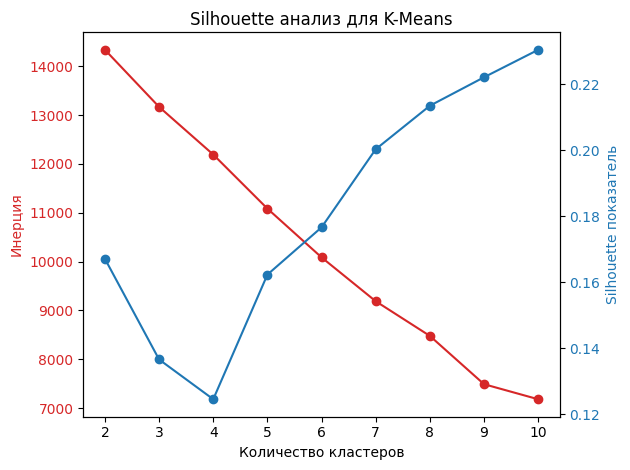

Оптимальное количество кластеров по силуэту: 10


In [19]:
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

fig, axes = plt.subplots()

# Elbow plot
color = 'tab:red'
axes.plot(K_range, inertias, marker='o', color=color)
axes.set_xlabel('Количество кластеров')
axes.set_ylabel('Инерция', color=color)
axes.tick_params(axis='y', labelcolor=color)

axes2 = axes.twinx()

# Silhouette plot
color = 'tab:blue'
axes2.plot(K_range, silhouette_scores, marker='o', color=color)
axes2.set_ylabel('Silhouette показатель', color=color)
axes2.set_title('Silhouette анализ для K-Means')
axes2.tick_params(axis='y', labelcolor=color)

plt.tight_layout()
plt.show()

optimal_k = K_range[np.argmax(silhouette_scores)]
print(f"Оптимальное количество кластеров по силуэту: {optimal_k}")

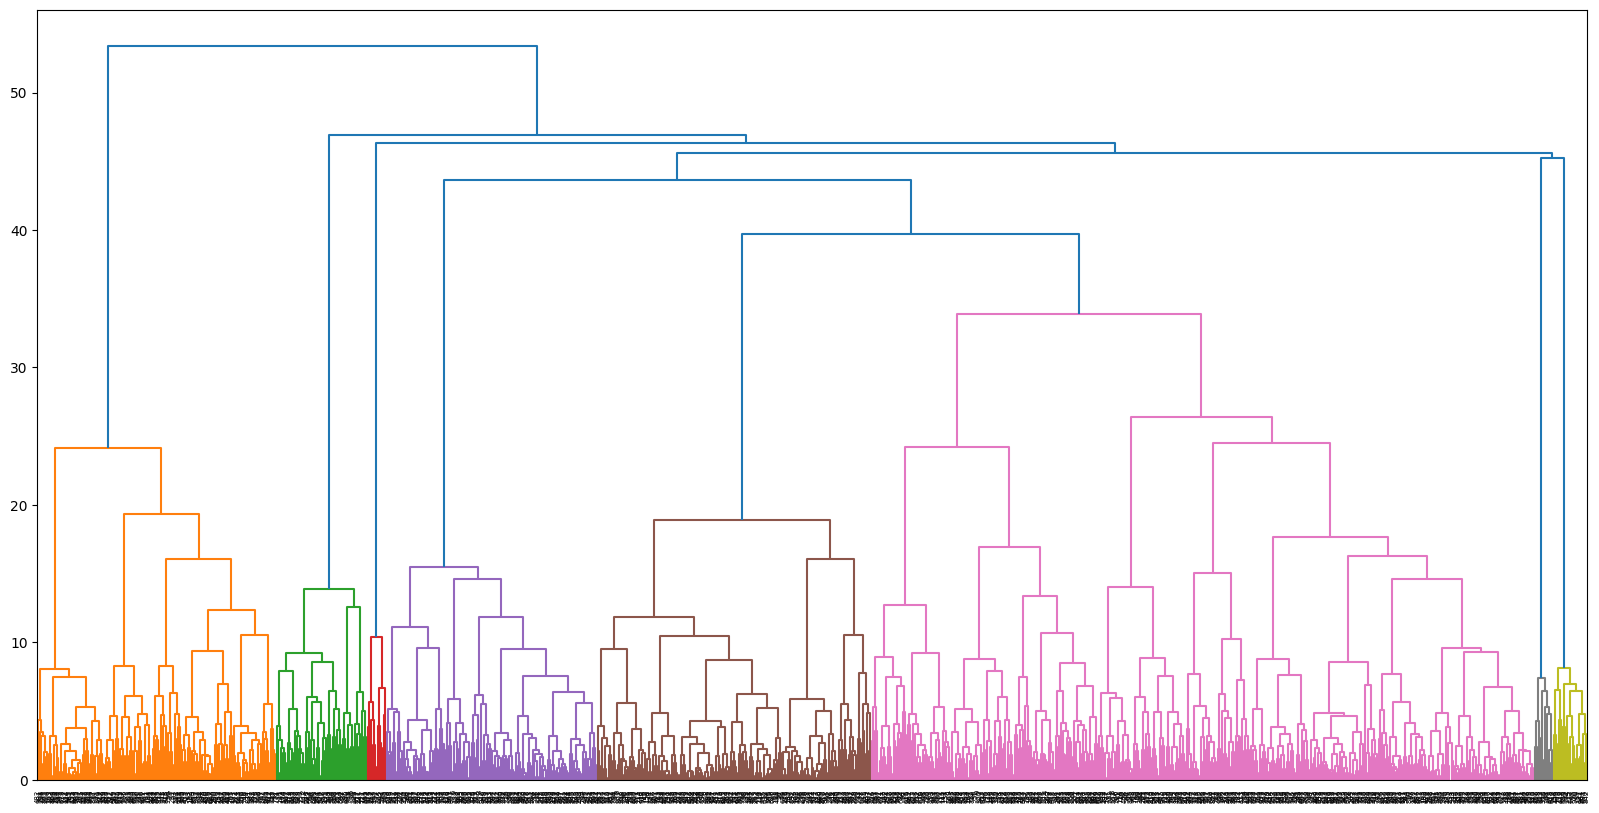

In [20]:
from scipy.cluster.hierarchy import dendrogram, linkage

plt.figure(figsize=(20,10))
linkage_ = linkage(X_scaled, method='ward')
dendrogram_ = dendrogram(linkage_)

In [21]:
from tqdm import tqdm
silhouette = []
for i in tqdm(range(2,11)):
    agg = AgglomerativeClustering(n_clusters=i).fit(X_scaled)
    labels = agg.labels_
    score = silhouette_score(X_scaled, labels)
    silhouette.append(score)

100%|██████████| 9/9 [00:00<00:00, 67.95it/s]


Оптимальное количество кластеров для иерархической: 6


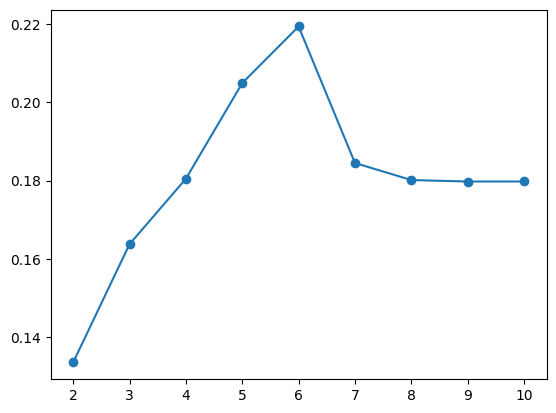

In [22]:
plt.plot(range(2,11), silhouette, marker='o')
optimal_k_hier = K_range[np.argmax(silhouette)]
print(f"Оптимальное количество кластеров для иерархической: {optimal_k_hier}")

In [23]:
X_scaled.shape

(1000, 16)

### Снижение размерности

In [24]:
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, random_state=10)
X_tsne = tsne.fit_transform(X_scaled)

In [25]:
X_tsne.shape

(1000, 2)

<Axes: >

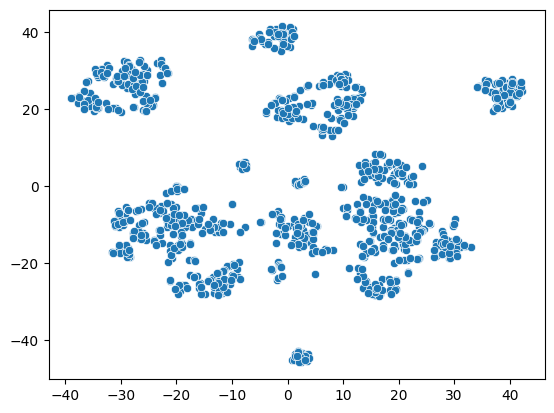

In [26]:
sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1])

In [27]:
agg = AgglomerativeClustering(n_clusters=optimal_k_hier).fit(X_scaled)
agg_labels = agg.labels_

<Axes: >

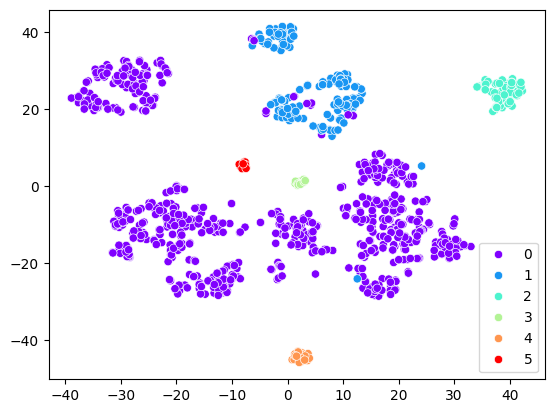

In [28]:
sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=agg_labels, palette='rainbow')

### При методе агломеративной кластеризации, разделение на группы данных выполняется не по принципу наименьшего расстояния между объектами, с учетом применения силуетной оценки под подходящему количеству кластеров. Вместо этого, один зи кластеров объединятеся в большую группу.

In [29]:
data_agg = data_cleaned

In [30]:
data_agg["labels"] = agg_labels

In [31]:
data_agg['labels'].value_counts(normalize=True)

labels
0    0.741
1    0.154
2    0.059
4    0.022
5    0.012
3    0.012
Name: proportion, dtype: float64

In [32]:
data_agg.groupby('labels').median().T.round(2)

labels,0,1,2,3,4,5
Age,34.0,26.0,36.0,39.5,33.5,28.0
Job,2.0,2.0,2.0,3.0,2.0,2.0
Credit amount,2359.0,2364.5,1597.0,6948.0,1749.0,1249.0
Duration,18.0,18.0,12.0,24.0,16.5,13.5
Saving_ord,1.0,1.0,1.0,1.0,1.0,1.0
Checking_ord,1.0,1.0,1.0,2.0,1.0,1.0
Sex_male,1.0,0.0,1.0,1.0,1.0,0.5
Housing_own,1.0,0.0,1.0,1.0,1.0,1.0
Housing_rent,0.0,1.0,0.0,0.0,0.0,0.0
Purpose_car,0.0,0.0,0.0,0.0,0.0,0.0


### Оценивание кластеров
Кластер 0: Мужчины-домовладельцы, средние кредиты <br>
Кластер 1: Женщины-арендаторы, средние кредиты <br>
Кластер 2: Образовательные кредиты, небольшие суммы <br>
Кластер 3: Дорогие кредиты на отдых, зрелые клиенты <br>
Кластер 4: Кредиты на ремонт, средние показатели <br>
Кластер 5: Молодежь на бытовую технику 

### DBSCAN

In [33]:
def dbscan_clustering(eps_range, X):
    eps_range = eps_range
    silhouette = []
    clusters = []
    for i in tqdm(eps_range):
        dbscan = DBSCAN(eps=i).fit(X)
        labels = dbscan.labels_
        uniq_labels = np.unique(labels)
        n_clusters = len(uniq_labels[uniq_labels != -1])
        if n_clusters > 1:
            score = silhouette_score(X, labels)
        else:
            score = 0
        silhouette.append(score)
        clusters.append(n_clusters)

    fig, ax1 = plt.subplots()

    color = 'tab:red'
    ax1.plot(eps_range, silhouette, marker='o', color=color)
    ax1.set_xlabel('eps')
    ax1.set_ylabel('silhouette', color=color)
    ax1.tick_params(axis='y', labelcolor=color)

    ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

    color = 'tab:blue'
    ax2.plot(eps_range, clusters, marker='o', color=color)
    ax2.set_ylabel('n_clusters', color=color)
    ax2.tick_params(axis='y', labelcolor=color)

    fig.tight_layout()  # otherwise the right y-label is slightly clipped
    plt.show()

100%|██████████| 190/190 [00:01<00:00, 144.72it/s]


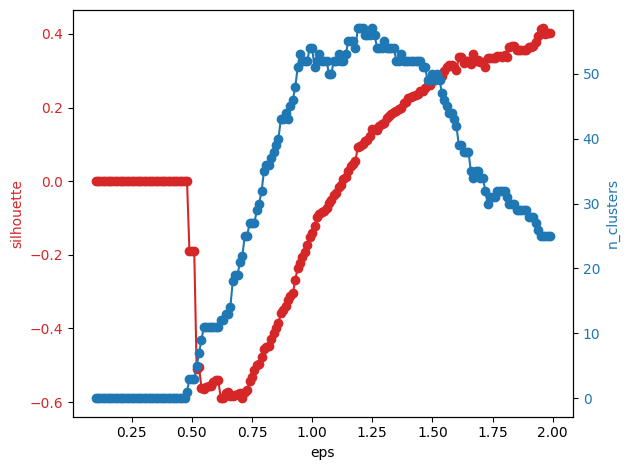

In [34]:
eps_range = np.arange(0.1,2,0.01)
dbscan_clustering(eps_range, X_tsne)

100%|██████████| 80/80 [00:00<00:00, 157.64it/s]


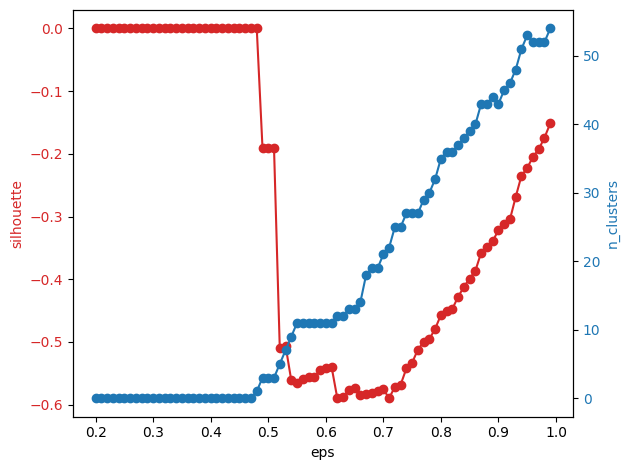

In [35]:
eps_range = np.arange(0.2,1,0.01)
dbscan_clustering(eps_range, X_tsne)

100%|██████████| 21/21 [00:00<00:00, 104.35it/s]


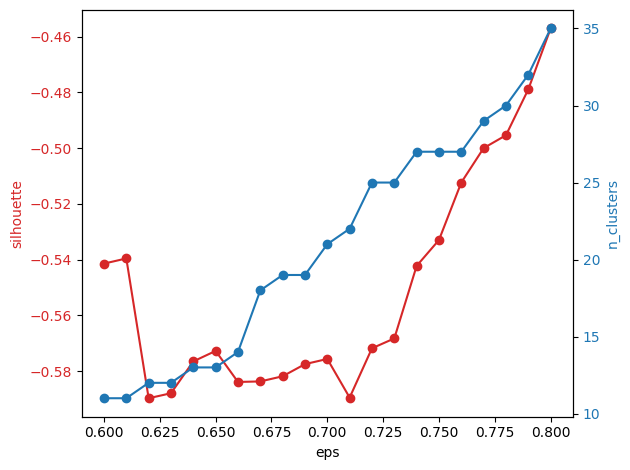

In [36]:
eps_range = np.arange(0.6,0.8,0.01)
dbscan_clustering(eps_range, X_tsne)

100%|██████████| 490/490 [00:03<00:00, 141.37it/s]


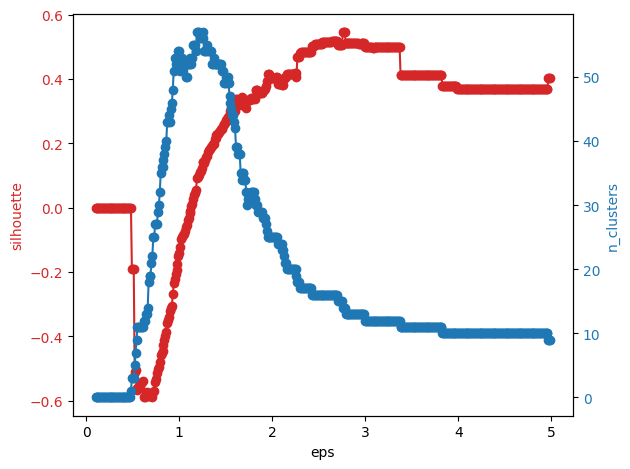

In [64]:
eps_range = np.arange(0.1,5.0,0.01)
dbscan_clustering(eps_range, X_tsne)

In [65]:
dbscan = DBSCAN(eps=3.5).fit(X_tsne)
dbs_labels = dbscan.labels_

In [66]:
n_noise = sum(dbs_labels == -1)
total = len(dbs_labels)
noise_percent = n_noise / total * 100

print(f"Шум: {n_noise} точек ({noise_percent:.1f}%)")
print(f"Кластеров: {len(set(dbs_labels)) - (1 if -1 in dbs_labels else 0)}")

Шум: 5 точек (0.5%)
Кластеров: 11


In [67]:
n_noise = sum(dbs_labels == -1)
total = len(dbs_labels)
noise_percent = n_noise / total * 100

print(f"Шум: {n_noise} точек ({noise_percent:.1f}%)")
print(f"Кластеров: {len(set(dbs_labels)) - (1 if -1 in dbs_labels else 0)}")

Шум: 5 точек (0.5%)
Кластеров: 11


<Axes: >

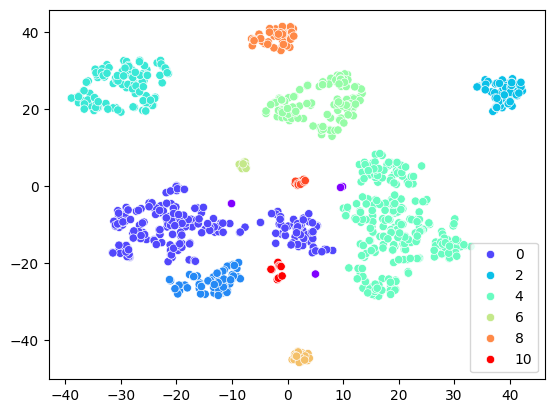

In [69]:
sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=dbs_labels, palette='rainbow')

In [70]:
import umap
# Выбираем лучшее количество кластеров для K-Means
best_k = optimal_k  # из расчетов выше
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_scaled)

# PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# t-SNE
X_tsne

# UMAP
reducer = umap.UMAP(random_state=42)
X_umap = reducer.fit_transform(X_scaled)

/Users/bot/Desktop/Study/ML_Level_2/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


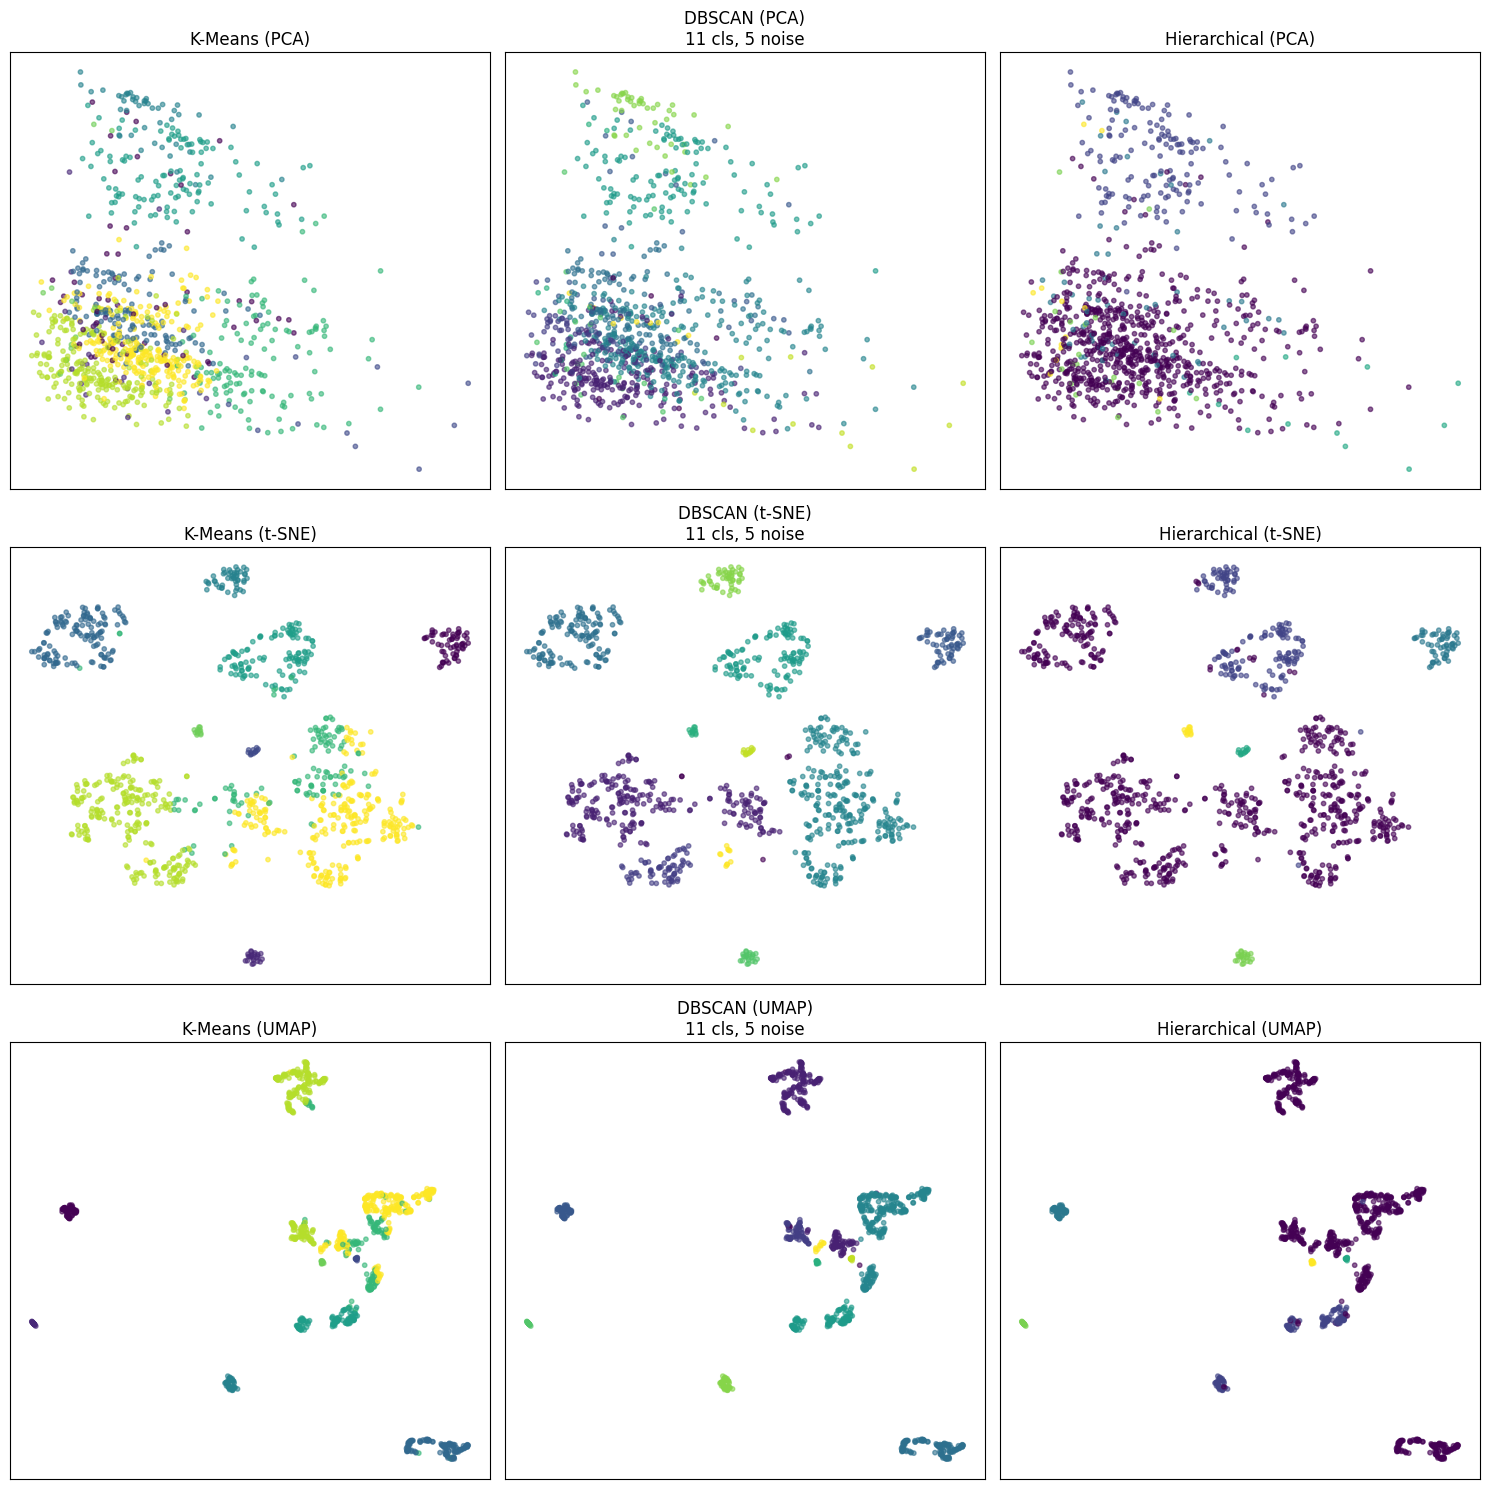

ИТОГОВЫЕ РЕЗУЛЬТАТЫ
K-Means: 10 кластеров
Иерархическая: 6 кластеров
DBSCAN: 11 кластеров, шум: 5 точек
PCA объясняет 12.5% + 12.1% = 24.6% дисперсии


In [71]:
# ВИЗУАЛИЗАЦИЯ - 3x3 сетка
all_labels = [kmeans_labels, dbs_labels, agg_labels]
X_models = [X_pca, X_tsne, X_umap]
model_names = ['PCA', 't-SNE', 'UMAP']  # названия методов сжатия
cluster_names = ['K-Means', 'DBSCAN', 'Hierarchical'] 

def report_visualization(X, labels):
      _, axes = plt.subplots(3, 3, figsize=(15, 15))
      for row, (X, model_name) in enumerate(zip(X_models, model_names)):
            for col, (labels, cluster_name) in enumerate(zip(all_labels, cluster_names)):
                  ax = axes[row, col]
                  
                  if cluster_name == 'DBSCAN':
                        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
                        n_noise = (labels == -1).sum()
                        ax.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=10, alpha=0.6)
                        ax.set_title(f'{cluster_name} ({model_name})\n{n_clusters} cls, {n_noise} noise')
                  else:
                        ax.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=10, alpha=0.6)
                        ax.set_title(f'{cluster_name} ({model_name})')
                  
                  ax.set_xticks([])
                  ax.set_yticks([])
      
      plt.tight_layout()
      plt.show()

report_visualization(X_models, all_labels)

# РЕЗУЛЬТАТЫ
print("="*50)
print("ИТОГОВЫЕ РЕЗУЛЬТАТЫ")
print("="*50)
print(f"K-Means: {len(np.unique(kmeans_labels))} кластеров")
print(f"Иерархическая: {len(np.unique(agg_labels))} кластеров")
print(f"DBSCAN: {len(np.unique(dbs_labels)) - (1 if -1 in dbs_labels else 0)} кластеров, "
      f"шум: {(dbs_labels==-1).sum()} точек")
print(f"PCA объясняет {pca.explained_variance_ratio_[0]*100:.1f}% + {pca.explained_variance_ratio_[1]*100:.1f}% = "
      f"{sum(pca.explained_variance_ratio_[:2])*100:.1f}% дисперсии")